# Simulador de Escalonamento de Tempo Real
## Eventos discretos: Rate Monotonic (RM), Deadline Monotonic (DM) e Earliest Deadline First (EDF)

Sistemas de Tempo Real (UFBA / IC) — **Luis Sena** e **Antoniel Magalhães**.

Este notebook é **autossuficiente**: rode **Ambiente de execução → Executar tudo**
(*Runtime → Run all*) e desça lendo. Cada seção mostra um pedaço do código e, no
fim, um diagrama de Gantt deixa claro quando cada algoritmo **cumpre** ou **perde**
um deadline.

## 1. Modelo: tarefa periódica e job

Toda a carga é descrita por duas estruturas:

- **`Tarefa`**: `tempo_execucao_pior_caso` (WCET), `periodo` e `deadline` relativo (usamos `deadline = periodo`).
- **`Job`**: uma instância concreta da tarefa. Guarda o `tempo_restante` de CPU e o `deadline` **absoluto**
  (liberação + prazo relativo), que será a chave do EDF.

Tempos aceitam **inteiros ou floats** (ex.: WCET = `1.5`).

In [44]:
from dataclasses import dataclass
from math import gcd, isclose
from typing import Callable, List, Optional, Tuple

Tempo = float
_EPS = 1e-9

def _esgotado(tempo_restante: Tempo) -> bool:
    return tempo_restante <= _EPS

@dataclass(frozen=True)
class Tarefa:
    id: int
    nome: str
    tempo_execucao_pior_caso: Tempo   # WCET (C)
    periodo: Tempo                    # intervalo entre liberações (T)
    deadline: Tempo                   # prazo relativo após liberação (D)

    @property
    def utilizacao(self) -> float:
        return self.tempo_execucao_pior_caso / self.periodo

@dataclass
class Job:
    tarefa: Tarefa
    indice: int
    liberacao: Tempo
    tempo_restante: Tempo
    deadline: Tempo                   # deadline absoluto = liberação + prazo relativo
    fim: Optional[Tempo] = None
    perdido: bool = False

    @property
    def nome(self) -> str:
        return f"{self.tarefa.nome}.{self.indice}"

    @property
    def id_tarefa(self) -> int:
        return self.tarefa.id

## 2. Cenários prontos

Três cargas embutidas para a demonstração: uma que todos cumprem, o caso clássico
onde o **RM falha e o EDF salva**, e uma de sobrecarga onde ninguém escapa.

In [45]:
CENARIOS = {
    "1": ("Sucesso: todos cumprem", [
        Tarefa(1, "T1", 1, 4, 4),
        Tarefa(2, "T2", 1, 5, 5),
        Tarefa(3, "T3", 2, 8, 8),
    ]),
    "2": ("RM falha, EDF cumpre (caso clássico)", [
        Tarefa(1, "T1", 2, 5, 5),
        Tarefa(2, "T2", 4, 7, 7),
    ]),
    "3": ("Sobrecarga: todos perdem", [
        Tarefa(1, "T1", 3, 5, 5),
        Tarefa(2, "T2", 5, 10, 10),
    ]),
}

## 3. Políticas de prioridade

A ideia central: **cada algoritmo é só uma função que devolve uma chave**, e a regra é
*menor chave = maior prioridade*. Trocar de algoritmo é trocar essa função; o motor é o mesmo.

In [46]:
def prioridade_rm(job: Job) -> Tuple:
    return (job.tarefa.periodo, job.tarefa.id)        # RM: menor período vence (estático)

def prioridade_dm(job: Job) -> Tuple:
    return (job.tarefa.deadline, job.tarefa.id)       # DM: menor deadline relativo vence (estático)

def prioridade_edf(job: Job) -> Tuple:
    return (job.deadline, job.tarefa.id)              # EDF: menor deadline absoluto vence (dinâmico)

POLITICAS = {
    "RM": ("Rate Monotonic", prioridade_rm),
    "DM": ("Deadline Monotonic", prioridade_dm),
    "EDF": ("Earliest Deadline First", prioridade_edf),
}

## 4. Métricas: utilização, hiperperíodo e limite do RM

- **Utilização** `U = Σ C/T`: fração da CPU exigida. `U > 1` é impossível de escalonar.
- **Hiperperíodo** (MMC dos períodos): simular esse intervalo basta para ver todo o padrão.
- **Limite de Liu & Layland**: se `U ≤ n(2^(1/n) − 1)`, o RM **garante** cumprir (teste suficiente).

In [47]:
from fractions import Fraction

def _lcm_frac(a: Fraction, b: Fraction) -> Fraction:
    return Fraction(
        a.numerator * b.numerator // gcd(a.numerator, b.numerator),
        gcd(a.denominator, b.denominator),
    )

def hiperperiodo(tarefas: List[Tarefa]) -> Tempo:
    h = Fraction(1)
    for t in tarefas:
        h = _lcm_frac(h, Fraction(str(t.periodo)))   # MMC dos períodos (T1=5,T2=7 -> 35)
    return float(h)

def utilizacao(tarefas: List[Tarefa]) -> float:
    return sum(t.utilizacao for t in tarefas)   # U = soma de C/T

def limite_de_utilizacao(n: int) -> float:
    return n * (2 ** (1 / n) - 1)               # n=2 -> 0,828; tende a ln2 ~= 0,693

## 5. O motor a eventos discretos

O relógio **salta de evento em evento**, nunca de 1 em 1: entre dois eventos nada muda,
o job de maior prioridade só executa. Dois tipos de evento movem a simulação:
`LIBERACAO_JOB` (nasce um job) e `TERMINO_JOB` (marco de quando o job ativo acabaria).

A **preempção surge sozinha**: quando um job de prioridade maior é liberado, no próximo
passo ele é escolhido e assume a CPU. A **perda de deadline** é observação derivada.

In [48]:
import heapq

class SimuladorEventosDiscretos:
    def __init__(self, tarefas, prioridade, horizonte):
        # --- configuração (entrada fixa da simulação) ---
        self.tarefas = tarefas
        self.mapa_tarefas = {t.id: t for t in tarefas}
        self.prioridade = prioridade            # troca RM/DM/EDF = troca esta função
        self.horizonte = horizonte

        # --- motor de eventos (relógio discreto) ---
        self.lista_eventos = []                 # heap de (tempo, ordem, tipo, dados)
        self._seq = 0                           # desempate estável no heap
        self.tempo_atual = 0

        # --- estado da CPU e fila de prontos ---
        self.job_ativo = None
        self.fila_prontos = []                  # jobs liberados esperando/na CPU
        self.contador_jobs = {t.id: 0 for t in tarefas}

        # --- saída / observabilidade (Gantt e veredito) ---
        self.historico = []                     # (inicio, fim, id_tarefa, deadline)
        self.deadlines_perdidas = []            # (deadline, nome_job)
        self.jobs_terminados = []

    def agendar_evento(self, tempo, tipo, dados):
        heapq.heappush(self.lista_eventos, (tempo, self._seq, tipo, dados))
        self._seq += 1

    def reordenar_fila_prontos(self):
        self.fila_prontos.sort(key=self.prioridade)     # menor chave fica em [0]

    def executar(self):
        # PASSO 1 (arranque): agenda a 1a liberação de cada tarefa em t = 0.
        for t in self.tarefas:
            self.agendar_evento(0, "LIBERACAO_JOB", t.id)

        while self.lista_eventos:
            tempo_evento, _, tipo, dados = heapq.heappop(self.lista_eventos)
            if tempo_evento > self.horizonte:
                break

            # PASSO 2: salta o relógio; o job ativo ocupou a CPU nesse intervalo.
            passo = tempo_evento - self.tempo_atual
            if passo > _EPS and self.job_ativo is not None:
                self.historico.append((self.tempo_atual, tempo_evento,
                                       self.job_ativo.id_tarefa, self.job_ativo.deadline))
                self.job_ativo.tempo_restante -= passo
            self.tempo_atual = tempo_evento

            if (self.job_ativo is not None and _esgotado(self.job_ativo.tempo_restante)
                    and self.job_ativo.fim is None):
                self._finalizar(self.job_ativo)
                self.job_ativo = None

            # PASSO 4: LIBERACAO cria job; TERMINO já foi tratado no passo 3.
            if tipo == "LIBERACAO_JOB":
                self._liberar(dados)

            # PASSO 5: marca deadlines vencidos entre os prontos.
            self._marcar_perdas()

            # PASSO 6: escolhe o job de maior prioridade e agenda seu término.
            self.reordenar_fila_prontos()
            self.job_ativo = self.fila_prontos[0] if self.fila_prontos else None
            if self.job_ativo is not None:
                self.agendar_evento(self.tempo_atual + self.job_ativo.tempo_restante,
                                    "TERMINO_JOB", self.job_ativo)

    def _liberar(self, id_tarefa):
        t = self.mapa_tarefas[id_tarefa]
        self.contador_jobs[id_tarefa] += 1
        job = Job(tarefa=t, indice=self.contador_jobs[id_tarefa], liberacao=self.tempo_atual,
                  tempo_restante=t.tempo_execucao_pior_caso,
                  deadline=self.tempo_atual + t.deadline)
        self.fila_prontos.append(job)
        prox = self.tempo_atual + t.periodo
        if prox <= self.horizonte:
            self.agendar_evento(prox, "LIBERACAO_JOB", id_tarefa)

    def _finalizar(self, job):
        job.fim = self.tempo_atual
        self.fila_prontos.remove(job)
        self.jobs_terminados.append(job)
        if job.fim > job.deadline and not job.perdido:   # terminou atrasado
            job.perdido = True
            self.deadlines_perdidas.append((job.deadline, job.nome))

    def _marcar_perdas(self):
        for job in self.fila_prontos:
            if not job.perdido and not _esgotado(job.tempo_restante) and job.deadline <= self.tempo_atual + _EPS:
                job.perdido = True
                self.deadlines_perdidas.append((job.deadline, job.nome))

    def pior_resposta(self, id_tarefa):
        r = [j.fim - j.liberacao for j in self.jobs_terminados
             if j.id_tarefa == id_tarefa and j.fim is not None]
        return max(r) if r else None

    @property
    def viavel(self):
        return not self.deadlines_perdidas

## 6. Diagrama de Gantt

Barras coloridas para execução **no prazo**, **vermelho** para o que vazou do deadline,
**X** onde o prazo foi perdido, ▲ verde nas liberações e linha tracejada nos deadlines.

In [49]:
import matplotlib.pyplot as plt

CORES = ["#4E79A7", "#59A14F", "#F28E2B", "#B07AA1", "#76B7B2", "#EDC948"]
VERMELHO = "#D62728"

def plotar_gantt(sim, algoritmo):
    tarefas, H = sim.tarefas, sim.horizonte
    perdidos = {d for d, _ in sim.deadlines_perdidas}
    fig, ax = plt.subplots(figsize=(min(2 + H * 0.42, 16), 1.5 + len(tarefas) * 0.9))

    for i, t in enumerate(tarefas):
        y = len(tarefas) - 1 - i                # T1 no topo
        cor = CORES[i % len(CORES)]
        for inicio, fim, id_tarefa, deadline in sim.historico:
            if id_tarefa != t.id:
                continue
            if fim <= deadline:                  # tudo no prazo
                ax.broken_barh([(inicio, fim - inicio)], (y + 0.15, 0.7),
                               facecolors=cor, edgecolor="black", linewidth=0.5)
            else:                                # parte no prazo + parte atrasada (vermelho)
                if deadline > inicio:
                    ax.broken_barh([(inicio, deadline - inicio)], (y + 0.15, 0.7),
                                   facecolors=cor, edgecolor="black", linewidth=0.5)
                ini_atraso = max(inicio, deadline)
                ax.broken_barh([(ini_atraso, fim - ini_atraso)], (y + 0.15, 0.7),
                               facecolors=VERMELHO, edgecolor="black", linewidth=0.5)
        k = 0
        while k * t.periodo <= H + _EPS:
            r = k * t.periodo
            ax.plot(r, y + 0.1, marker="^", color="#2CA02C", markersize=8, clip_on=False)
            d = r + t.deadline
            if d <= H + _EPS:
                perdido = any(isclose(d, pd, abs_tol=_EPS) for pd in perdidos)
                ax.plot([d, d], [y + 0.1, y + 0.9], linestyle="--", linewidth=1.4,
                        color=VERMELHO if perdido else "#888888")
                if perdido:
                    ax.plot(d, y + 0.9, marker="x", color=VERMELHO, markersize=10, mew=2.5)
            k += 1

    ax.set_yticks([len(tarefas) - 1 - i + 0.5 for i in range(len(tarefas))])
    ax.set_yticklabels([t.nome for t in tarefas])
    if isclose(H, round(H), abs_tol=_EPS):
        ax.set_xticks(range(0, int(round(H)) + 1))
    ax.set_xlim(0, H)
    ax.set_ylim(0, len(tarefas))
    ax.set_xlabel("Tempo (unidades)")
    ax.set_ylabel("Tarefas")
    ax.grid(axis="x", linestyle=":", alpha=0.4)

    status = "CUMPRE TODOS OS DEADLINES" if sim.viavel else f"PERDE {len(sim.deadlines_perdidas)} DEADLINE(S)"
    cor_status = "#2CA02C" if sim.viavel else VERMELHO
    ax.set_title(f"Escalonamento de Tempo Real - {algoritmo}", fontweight="bold", fontsize=13, pad=30)
    ax.text(0.5, 1.06, status, transform=ax.transAxes, ha="center", va="bottom",
            color=cor_status, fontweight="bold", fontsize=11)
    fig.tight_layout()
    plt.show()

## 7. Função que roda um cenário e imprime o veredito

`rodar(cenario, algoritmo)` monta o simulador, executa, imprime o resumo e desenha o Gantt.

In [50]:
def rodar(cenario, algoritmo):
    _, tarefas = CENARIOS[cenario]
    nome_alg, prioridade = POLITICAS[algoritmo]
    H = hiperperiodo(tarefas)
    sim = SimuladorEventosDiscretos(tarefas, prioridade, horizonte=H)
    sim.executar()

    U, n = utilizacao(tarefas), len(tarefas)
    print(f"   limite_de_utilizacao({n}) = {limite_de_utilizacao(n):.3f}   "
          f"teste EDF: U<=1 -> {'ok' if U <= 1 else 'sobrecarga'}")
    for t in tarefas:
        pr = sim.pior_resposta(t.id)
        estado = "n/d" if pr is None else ("OK" if pr <= t.deadline + _EPS else f"PERDA (D={t.deadline})")
        print(f"   {t.nome}: pior tempo de resposta = {pr}   {estado}")
    if sim.viavel:
        print("   ✅ Sucesso: nenhuma deadline perdida no hiperperíodo.")
    else:
        nomes = ", ".join(sorted({nm for _, nm in sim.deadlines_perdidas}))
        print(f"   ❌ Falha: {len(sim.deadlines_perdidas)} deadline(s) perdida(s): {nomes}")

    plotar_gantt(sim, nome_alg)
    return sim

## 8. Demonstração: RM perde o deadline

Cenário 2: `T1` pede 2 a cada 5, `T2` pede 4 a cada 7 (`U = 0,97 < 1`). Em `t=5`, `T1`
(período menor) preempta `T2`. Quando o deadline de `T2` chega em `t=7`, ainda faltava
1 unidade: **perda** (bloco vermelho + X). Pior resposta de `T2 = 8 > 7`.

   limite_de_utilizacao(2) = 0.828   teste EDF: U<=1 -> ok
   T1: pior tempo de resposta = 2   OK
   T2: pior tempo de resposta = 8   PERDA (D=7)
   ❌ Falha: 1 deadline(s) perdida(s): T2.1


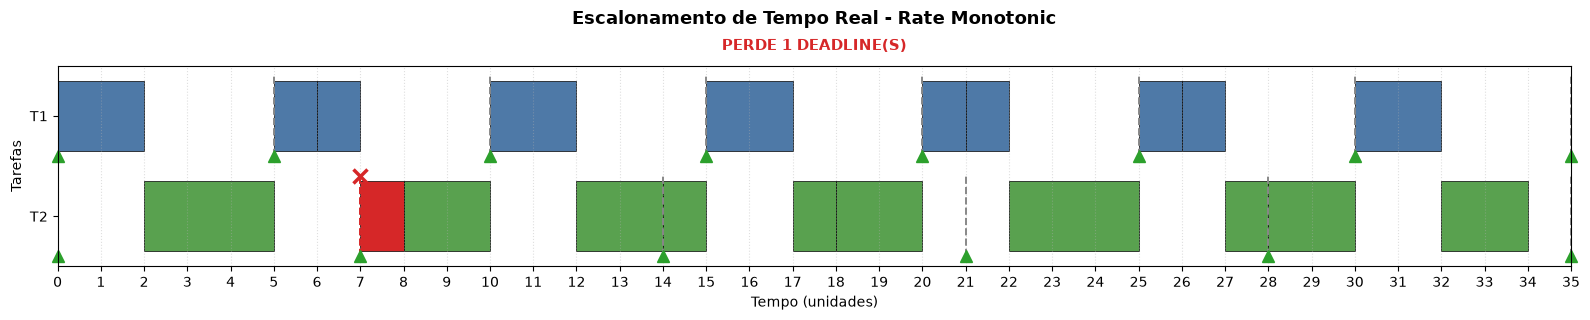

In [51]:
rm = rodar('2', 'RM')

## 9. Demonstração: EDF cumpre todos

Mesma carga. A diferença nasce em `t=2`: o EDF olha o deadline **absoluto**. `T2` vence em 7,
`T1` vence em 10, então o EDF deixa `T2` terminar primeiro, em `t=6`, antes do prazo. Sem
bloco vermelho, sem X: título verde.

   limite_de_utilizacao(2) = 0.828   teste EDF: U<=1 -> ok
   T1: pior tempo de resposta = 4   OK
   T2: pior tempo de resposta = 6   OK
   ✅ Sucesso: nenhuma deadline perdida no hiperperíodo.


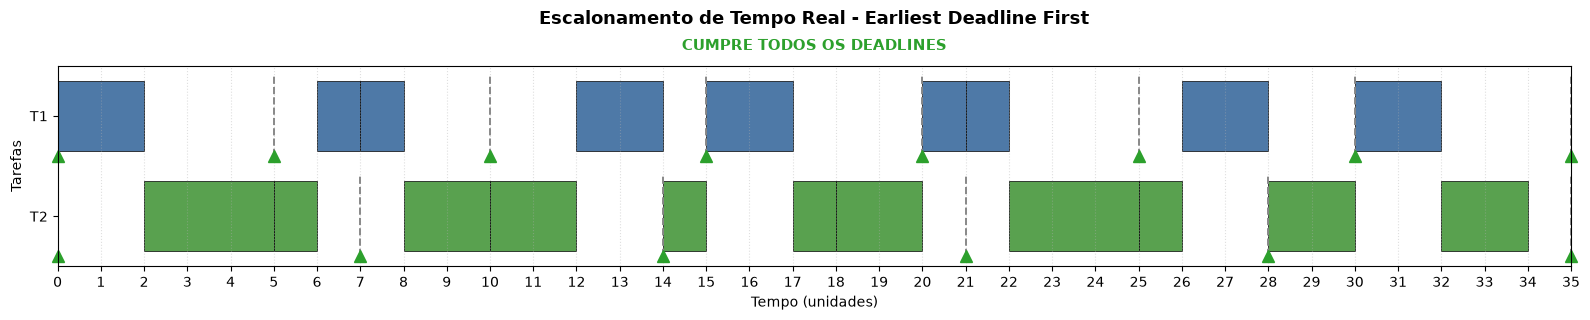

In [52]:
edf = rodar('2', 'EDF')

## 10. Cenário de sucesso (três tarefas)

Utilização baixa: os dois algoritmos cumprem, como o teste garante.

   limite_de_utilizacao(3) = 0.780   teste EDF: U<=1 -> ok
   T1: pior tempo de resposta = 1   OK
   T2: pior tempo de resposta = 2   OK
   T3: pior tempo de resposta = 4   OK
   ✅ Sucesso: nenhuma deadline perdida no hiperperíodo.


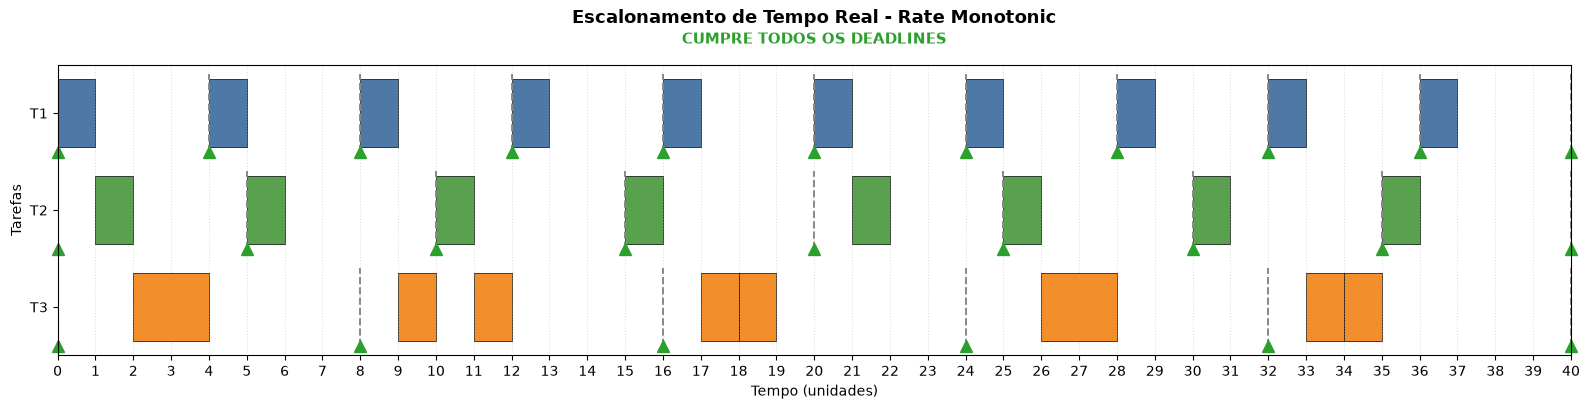

In [53]:
_ = rodar('1', 'RM')

## 11. Cenário de sobrecarga

`U = 1,10 > 1`: não existe algoritmo que salve. Os dois perdem, e isso está certo.

   limite_de_utilizacao(2) = 0.828   teste EDF: U<=1 -> sobrecarga
   T1: pior tempo de resposta = 3   OK
   T2: pior tempo de resposta = None   n/d
   ❌ Falha: 1 deadline(s) perdida(s): T2.1


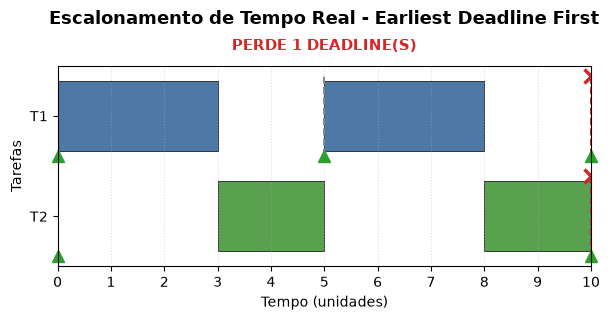

In [54]:
_ = rodar('3', 'EDF')

## 12. Interativo

Escolha o cenário e o algoritmo nos menus e o Gantt é redesenhado na hora.

In [55]:
try:
    from ipywidgets import interact, Dropdown
    interact(
        lambda cenario, algoritmo: rodar(cenario, algoritmo),
        cenario=Dropdown(options=[(f"{k}) {v[0]}", k) for k, v in CENARIOS.items()], value="2"),
        algoritmo=Dropdown(options=["RM", "DM", "EDF"], value="RM"),
    )
except Exception as e:
    print("ipywidgets indisponível; use as células acima.", e)

interactive(children=(Dropdown(description='cenario', index=1, options=(('1) Sucesso: todos cumprem', '1'), ('…